###Load & Explore CUAD Dataset

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import torch


In [ ]:
import json
from google.colab import files
uploaded = files.upload()

Saving CUAD_v1.json to CUAD_v1 (1).json


In [ ]:
import os

In [ ]:
# Load the full JSON file (adjust path if needed)
with open("CUAD_v1.json", "r") as f:
    cuad_data = json.load(f)

# See top-level keys (usually contract names)
list(cuad_data.keys())[:5]  # Preview first 3 contract names

['version', 'data']

In [ ]:
# Preview one contract's annotation structure
contract_name = list(cuad_data.keys())[0]
cuad_data[contract_name]

'aok_v1.0'

#####Extracts the first substring enclosed in double quotes in the dataset

In [ ]:
def find_text(text):
    start = text.find('"')
    end = text.find('"', start + 1)

    if start != -1 and end != -1:
        return text[start+1:end]
    else:
        return None


In [ ]:
def extract_label(contract):
    labels_in_contract = []
    for paragraph in contract["paragraphs"]:
        labels_in_paragraph = []
        for qas in paragraph["qas"]:
            label = find_text(qas["question"])
            if label:
                labels_in_paragraph.append(label)
        labels_in_contract.append(labels_in_paragraph)
    return labels_in_contract


In [ ]:
with open("CUAD_v1.json", "r") as f:
    data = json.load(f)['data']

def extract_labels(data):
    results = []

    for contract in data:
        for paragraph in contract['paragraphs']:
            labels_in_paragraph = []

            for qa in paragraph['qas']:
                if qa['is_impossible'] == False:
                    label = find_text(qa['question'])
                    labels_in_paragraph.append(label)

            results.append({
                "text": paragraph['context'],  # check this field exists
                "labels": labels_in_paragraph
            })

    return results


In [ ]:
labelled_paragraphs = extract_labels(data)
for entry in labelled_paragraphs[:3]:
    print(entry['labels'])
    print(entry['text'][:150] + '...')
    print("—" * 50)


['Document Name', 'Parties', 'Agreement Date', 'Effective Date', 'Expiration Date', 'Renewal Term', 'Governing Law', 'Exclusivity', 'No-Solicit Of Customers', 'No-Solicit Of Employees', 'Rofr/Rofo/Rofn', 'Anti-Assignment', 'Price Restrictions', 'Minimum Commitment', 'License Grant', 'Post-Termination Services', 'Warranty Duration', 'Insurance', 'Covenant Not To Sue']
EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between El...
——————————————————————————————————————————————————
['Document Name', 'Parties', 'Effective Date', 'Expiration Date', 'Governing Law', 'Change Of Control', 'Anti-Assignment', 'License Grant', 'Audit Rights', 'Uncapped Liability', 'Cap On Liability', 'Warranty Duration']
Exhibit 10.26    CONFIDENTIAL TREATMENT HAS BEEN REQUESTED AS TO CERTAIN PORTIONS OF THIS DOCUMENT. EACH SUCH PORTION,  WHICH HAS BEEN OMITTED HEREIN ...
——————————————————————————————————————————————————
[

###Building Clause Co-occurrence Map and Document-Label Matrix

In [ ]:
from collections import defaultdict, Counter
import itertools, json

def build_doc_clause_map(data):
    clause_types = set()
    clause_frequency = Counter()
    document_clause_map = {}
    co_occurrence = defaultdict(Counter)
    empty_docs = []

    # 1) First pass: collect all clause labels + per-doc sets
    for contract in data:
        title = contract.get('title', '')
        paragraphs = contract.get('paragraphs', [])
        clause_set = set()

        for para in paragraphs:
            for qa in para.get('qas', []):
                if not qa.get('is_impossible', False):
                    # CUAD ids usually end with "__Label"
                    qa_id = qa.get('id', '')
                    label = qa_id.split("__")[-1] if "__" in qa_id else qa_id
                    if label:
                        clause_types.add(label)
                        clause_set.add(label)
                        clause_frequency[label] += 1

        full_context = " ".join(
            (p.get('context', '') or '').strip()
            for p in paragraphs if isinstance(p.get('context', ''), str)
        )

        if not full_context.strip():
            empty_docs.append(title)

        document_clause_map[title] = {
            "clauses": clause_set,
            "context": full_context
        }

    # 2) Fixed global mapping after scanning everything
    clause_to_idx = {clause: i for i, clause in enumerate(sorted(clause_types))}

    # 3) Co-occurrence and label vectors using fixed mapping
    for title, info in document_clause_map.items():
        cset = info["clauses"]
        # co-occurrence
        for a, b in itertools.combinations(sorted(cset), 2):
            co_occurrence[a][b] += 1
            co_occurrence[b][a] += 1
        # multi-hot vector
        vec = [0] * len(clause_to_idx)
        for c in cset:
            vec[clause_to_idx[c]] = 1
        info["label_vector"] = vec

    return document_clause_map, co_occurrence, empty_docs, clause_to_idx, clause_frequency


In [ ]:
clause_labels = sorted(list(clause_to_idx.keys()))
print(f"Clause Labels({len(clause_labels)}):")
print(clause_labels[:5])

document_clause_map, co_occ, empty_docs, clause_to_idx, clause_freq = build_doc_clause_map(data)



# save for inference (artifacts folder)
import os
os.makedirs("artifacts", exist_ok=True)
with open("artifacts/clause_to_idx.json", "w") as f:
    json.dump(clause_to_idx, f, indent=2)


Clause Labels(41):
['Affiliate License-Licensee', 'Affiliate License-Licensor', 'Agreement Date', 'Anti-Assignment', 'Audit Rights']


# ==== Setup ====

In [ ]:
!pip -q install transformers==4.42.4 datasets==2.20.0 accelerate==0.33.0 evaluate==0.4.2 scikit-learn==1.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 103.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 require

###Tokenization

In [ ]:
def convert_CUAD_to_QA_dataset(document_clause_map, clause_to_index):
    data_list = []
    for title, doc_info in document_clause_map.items():
        context = doc_info['context']
        label_vector = doc_info['label_vector']

        for clause in clause_to_index:
            question = f"Does this contract contain a {clause} clause?"
            example = {
                "question": question,
                "context": context,
                "labels": label_vector
            }
            data_list.append(example)

    return data_list


In [ ]:
data_list = convert_CUAD_to_QA_dataset(document_clause_map,clause_to_idx)
print(data_list[0])

{'question': 'Does this contract contain a Affiliate License-Licensee clause?', 'context': 'EXHIBIT 10.6\n\n                              DISTRIBUTOR AGREEMENT\n\n         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Company")  and Electric City of Illinois LLC ("Distributor") this 7th day of September, 1999.\n\n                                    RECITALS\n\n         A. The  Company\'s  Business.  The Company is  presently  engaged in the business  of selling an energy  efficiency  device,  which is  referred to as an "Energy  Saver"  which may be improved  or  otherwise  changed  from its present composition (the "Products").  The Company may engage in the business of selling other  products  or  other  devices  other  than  the  Products,  which  will be considered  Products if Distributor  exercises its options pursuant to Section 7 hereof.\n\n         B. Representations.  As an inducement to the Company to

In [ ]:
!pip install -U transformers datasets accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 108.0 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.42.4
    Uninstalling transformers-4.42.4:
      Successfully uninstalled transformers-4.42.4
  Attempting uninstall: datasets
    Found existing installation: datasets 2.20.0
    Uninstalling datasets-2.20.0:
      Successfully uninstalled datasets-2.20.0
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.33.0
  

####Tokenization

In [ ]:
import sys, numpy as np, platform
print("Python:", platform.python_version())
print("NumPy:", np.__version__, "->", np.__file__)
print("Site-packages paths:\n", "\n".join(sys.path[:5]))


Python: 3.12.11
NumPy: 2.0.2 -> /usr/local/lib/python3.12/dist-packages/numpy/__init__.py
Site-packages paths:
 /content
/env/python
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload


In [ ]:
# 0) make sure no local files shadow packages
import os, glob
print([p for p in glob.glob("./*") if os.path.basename(p) in {"numpy","transformers","datasets","tokenizers"} or os.path.splitext(p)[0] in {"numpy","transformers","datasets","tokenizers"}])


[]


In [ ]:
!pip install -U pip setuptools wheel


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 68.0 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
!pip install --no-cache-dir "numpy==1.26.4"


In [ ]:
!pip install --upgrade --no-cache-dir \
  "transformers>=4.44.0" \
  "tokenizers>=0.15.2" \
  "datasets>=2.19.0" \
  "accelerate>=0.31.0" \
  "huggingface-hub>=0.23.0" \
  "safetensors>=0.4.3" \
  "pyarrow>=15.0.0"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 228.0 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 21.0.0 which is incompatible.


In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

# Use Legal Pro BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained("AmitTewari/LegalPro-BERT-base")
#wrap dataset into Huggingface dataset
full_dataset = Dataset.from_list(data_list)

def tokenize_contexts_full_dataset(dataset, tokenizer, max_length=512):
    def tokenize(example_batch):
        questions = example_batch["question"]
        context   = example_batch["context"]
        encoding = tokenizer(
            questions,
            context,
            padding="max_length",
            truncation=True,
            max_length=max_length
        )
        encoding["labels"] = example_batch["labels"]
        return encoding

    tokenized_dataset = dataset.map(
        tokenize,
        batched=True,
        remove_columns=["question", "context"]
    )
    return tokenized_dataset

tokenized_dataset = tokenize_contexts_full_dataset(full_dataset, tokenizer)
# (optional) prepare for PyTorch dataloaders
tokenized_dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])


Map:   0%|          | 0/20910 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset = tokenize_contexts_full_dataset(full_dataset, tokenizer)
tokenized_dataset[0]

Map:   0%|          | 0/20910 [00:00<?, ? examples/s]

{'labels': [0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  1],
 'input_ids': [101,
  2515,
  2023,
  3206,
  5383,
  1037,
  8727,
  6105,
  1011,
  6105,
  2063,
  11075,
  1029,
  102,
  8327,
  2184,
  1012,
  1020,
  16632,
  3820,
  2023,
  16632,
  3820,
  1006,
  1996,
  1000,
  3820,
  1000,
  1007,
  2003,
  2081,
  2011,
  1998,
  2090,
  3751,
  2103,
  13058,
  1012,
  1010,
  1037,
  8452,
  3840,
  1006,
  1000,
  2194,
  1000,
  1007,
  1998,
  3751,
  2103,
  1997,
  4307,
  11775,
  1006,
  1000,
  16632,
  1000,
  1007,
  2023,
  5504,
  2154,
  1997,
  2244,
  1010,
  2639,
  1012,
  25521,
  2015,
  1037,
  1012,
  1996,
  2194,
  1005,
  1055,
  2449,
  1012,
  1996,
  2194,
  2003,
  12825,
  5117,
  1999,
  1996,
  2449,
  1997,
  4855,
  2019,
  2943,
  8122,
  5080,
  1010,
  2029,
  2003,
  3615,
  2000,
  200

####Legal ProBert Model Development

In [ ]:
#Libarary Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from torch.nn import BCEWithLogitsLoss

In [ ]:
from transformers import AutoModel, AutoTokenizer
import torch.nn as nn
from torch.optim import AdamW

In [ ]:
from transformers import AutoModel
import torch.nn as nn

class LegalProBertClauseClassifier(nn.Module):
    def __init__(self, num_labels: int = 41, dropout: float = 0.3):
        super(LegalProBertClauseClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained("AmitTewari/LegalPro-BERT-base")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] embedding
        x = self.dropout(cls_output)
        logits = self.classifier(x)
        return logits


In [ ]:
class ClauseDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels_list):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels_list = labels_list

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_masks[idx], dtype=torch.long),
            'labels_list': torch.tensor(self.labels_list[idx], dtype=torch.float)
        }


In [ ]:
input_ids_list = []
attention_mask_list = []
labels_list = []

for doc, info in document_clause_map.items():
    context = info["context"]
    label_vector = info["label_vector"]

    # Skip empty context
    if context.strip() == "":
        continue

    # Tokenize
    encoded = tokenizer(
        context,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors=None  # so we get plain lists
    )

    input_ids_list.append(encoded["input_ids"])
    attention_mask_list.append(encoded["attention_mask"])
    labels_list.append(label_vector)


###Evaluation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
import torch

@torch.no_grad()
def evaluate_model(model, val_loader, device, threshold=0.5, zero_division=0):
    """
    Evaluate multi-label classifier.

    threshold:
      - float (global) or np.ndarray of shape (num_labels,) for per-class thresholds.
    Returns:
      df (pd.DataFrame): classification_report as DataFrame
      y_probs (np.ndarray): (N, C) sigmoid probabilities
      y_true (np.ndarray): (N, C) ground-truth 0/1
    """
    model.eval()
    probs_all, labels_all = [], []

    for batch in val_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Handle either 'labels' or 'labels_list'
        if "labels" in batch:
            labels = batch["labels"].to(device)
        else:
            labels = batch["labels_list"].to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits)

        probs_all.append(probs.cpu())
        labels_all.append(labels.cpu())

    y_probs = torch.cat(probs_all, dim=0).numpy()
    y_true  = torch.cat(labels_all, dim=0).numpy()

    # Thresholding: global or per-class
    if isinstance(threshold, (list, np.ndarray)):
        thr = np.asarray(threshold)
        y_pred = (y_probs >= thr).astype(int)
        thr_print = "per-class"
    else:
        y_pred = (y_probs >= float(threshold)).astype(int)
        thr_print = f"{float(threshold):.2f}"

    report = classification_report(
        y_true, y_pred, output_dict=True, zero_division=zero_division
    )
    df = pd.DataFrame(report).transpose()

    print(f"\nThreshold: {thr_print}")
    print(f"MICRO Precision:  {df.loc['micro avg','precision']:.4f}")
    print(f"MICRO Recall:     {df.loc['micro avg','recall']:.4f}")
    print(f"MICRO F1 Score:   {df.loc['micro avg','f1-score']:.4f}")
    print(f"MACRO Precision:  {df.loc['macro avg','precision']:.4f}")
    print(f"MACRO Recall:     {df.loc['macro avg','recall']:.4f}")
    print(f"MACRO F1 Score:   {df.loc['macro avg','f1-score']:.4f}")

    return df, y_probs, y_true


####Model Training

In [ ]:
import os, json
import torch
import pandas as pd
import numpy as np

In [ ]:
''''import torch
import numpy as np
import pandas as pd
import os  # ← NEW: one-time import

def train_model(
    model,
    train_loader,
    val_loader,
    loss_func,
    optimiser,
    device,
    num_epochs=3,
    eval_threshold=0.3,
    scheduler=None,       # optional
    patience=None,        # e.g. 2 for early stopping; None to disable
    clip_norm=None,       # e.g. 1.0 to enable grad clipping
    # ---- NEW optional save knobs (defaults keep prior behavior) ----
    artifact_dir=None,                # e.g., "artifacts" or None to skip saving
    model_name="legalpro_bert_clause_cls",
    label_map=None,                   # dict {clause: idx}; if provided, will be saved
    save_checkpoint=True              # if artifact_dir is given, save .pt when True
):
    model.to(device)
    best_f1 = -1.0
    best_model_state = None
    average_epoch_loss = []
    wait = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train()
        epoch_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = (batch.get("labels") or batch.get("labels_list")).to(device)

            optimiser.zero_grad(set_to_none=True)
            logits = model(input_ids, attention_mask)
            loss = loss_func(logits, labels)
            loss.backward()

            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)

            optimiser.step()
            if scheduler is not None:
                scheduler.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / max(1, num_batches)
        average_epoch_loss.append(avg_loss)
        print(f"Average training loss: {avg_loss:.4f}")

        # Evaluate
        df_val, y_probs, y_true = evaluate_model(model, val_loader, device, threshold=eval_threshold)
        f1_epoch = float(df_val.loc["micro avg", "f1-score"])

        # Track best
        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            if patience is not None:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    print(f"\nBest Micro F1 Score: {best_f1:.4f}")
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    else:
        print("Warning: best_model_state was never set (no improvement recorded).")

    # ---- NEW: save artifacts (only if artifact_dir is provided) ----
    if artifact_dir:
        os.makedirs(artifact_dir, exist_ok=True)
        if save_checkpoint:
            ckpt_path = os.path.join(artifact_dir, f"{model_name}_best.pt")
            torch.save({"state_dict": model.state_dict(), "best_thr": eval_threshold}, ckpt_path)
            print(f"Saved checkpoint -> {ckpt_path}")
        if label_map is not None:
            import json
            lm_path = os.path.join(artifact_dir, "clause_to_idx.json")
            with open(lm_path, "w") as f:
                json.dump(label_map, f, indent=2)
            print(f"Saved label map -> {lm_path}")
    # ---------------------------------------------------------------

    return model, average_epoch_loss''''


In [ ]:
import torch
import numpy as np
import pandas as pd

def train_model(
    model,
    train_loader,
    val_loader,
    loss_func,
    optimiser,
    device,
    num_epochs=3,
    eval_threshold=0.3,
    scheduler=None,       # optional
    patience=None,        # e.g. 2 for early stopping; None to disable
    clip_norm=None        # e.g. 1.0 to enable grad clipping
):
    model.to(device)
    best_f1 = -1.0
    best_model_state = None
    average_epoch_loss = []
    wait = 0

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        model.train()
        epoch_loss = 0.0
        num_batches = 0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = (batch.get("labels") or batch.get("labels_list")).to(device)

            optimiser.zero_grad(set_to_none=True)
            logits = model(input_ids, attention_mask)
            loss = loss_func(logits, labels)
            loss.backward()

            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)

            optimiser.step()
            if scheduler is not None:
                scheduler.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / max(1, num_batches)
        average_epoch_loss.append(avg_loss)
        print(f"Average training loss: {avg_loss:.4f}")

        # Evaluate
        df_val, y_probs, y_true = evaluate_model(model, val_loader, device, threshold=eval_threshold)
        f1_epoch = float(df_val.loc["micro avg", "f1-score"])

        # Track best
        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            if patience is not None:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    print(f"\nBest Micro F1 Score: {best_f1:.4f}")
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    else:
        print("Warning: best_model_state was never set (no improvement recorded).")

    return model, average_epoch_loss


In [ ]:
import torch

def get_pos_weight(y_train, device):
    """
    Compute pos_weight for BCEWithLogitsLoss as (negatives / positives) per class.

    y_train: torch.Tensor of shape (num_samples, num_labels) with 0/1 entries
    device: torch.device
    """
    if not torch.is_tensor(y_train):
        y_train = torch.tensor(y_train, dtype=torch.float32)

    pos = y_train.sum(dim=0)            # positives per label
    neg = y_train.size(0) - pos         # negatives per label
    pos_weight = neg / (pos + 1e-9)     # ratio
    return pos_weight.to(device)


In [ ]:
from torch.utils.data import DataLoader, random_split


# Example with ClauseDataset
dataset = ClauseDataset(input_ids_list, attention_mask_list, labels_list)

total_size = len(dataset)
gen = torch.Generator().manual_seed(42)

p_train, p_val, p_test = 0.8, 0.1, 0.1


# Split 80/20
train_size = int(0.8 * len(dataset))
val_size   = int(p_val   * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size],generator=gen)

if test_size == 0:
    test_size = 1
    if train_size > val_size:
        train_size -= 1
    else:
        val_size -= 1
if val_size == 0 and total_size >= 2:
    val_size = 1
    train_size -= 1




# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle = False)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [ ]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

408 51 51


In [ ]:
# Collect all training labels into one tensor
all_train_labels = []
for batch in train_loader:
    if "labels" in batch:
        all_train_labels.append(batch["labels"])
    else:
        all_train_labels.append(batch["labels_list"])

y_train = torch.cat(all_train_labels, dim=0)  # shape: (num_train_samples, num_labels)


In [ ]:

print(os.__file__)


/usr/lib/python3.12/os.py


In [ ]:
# Prepare data
dataset = ClauseDataset(input_ids_list, attention_mask_list, labels_list)
#dataset = ClauseDataset(texts, labels_list, tokenizer)  # pass tokenizer + raw texts

# Split into train/val
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

# Initialize model, optimizer, loss
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LegalProBertClauseClassifier()
loss_func = BCEWithLogitsLoss()
optimiser = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
eval_threshold = 0.30
pos_weight = get_pos_weight(y_train, device)
# Train the model
model, train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimiser=optimiser,
    device=device,
    num_epochs=5
)




config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]


Epoch 1/5
Average training loss: 0.5062

Threshold: 0.30
MICRO Precision:  0.5742
MICRO Recall:     0.7965
MICRO F1 Score:   0.6673
MACRO Precision:  0.2999
MACRO Recall:     0.4651
MACRO F1 Score:   0.3401

Epoch 2/5
Average training loss: 0.4408

Threshold: 0.30
MICRO Precision:  0.6073
MICRO Recall:     0.7972
MICRO F1 Score:   0.6894
MACRO Precision:  0.3195
MACRO Recall:     0.4639
MACRO F1 Score:   0.3574

Epoch 3/5
Average training loss: 0.4143

Threshold: 0.30
MICRO Precision:  0.6592
MICRO Recall:     0.7618
MICRO F1 Score:   0.7068
MACRO Precision:  0.3937
MACRO Recall:     0.4433
MACRO F1 Score:   0.3848

Epoch 4/5
Average training loss: 0.3862

Threshold: 0.30
MICRO Precision:  0.6753
MICRO Recall:     0.7714
MICRO F1 Score:   0.7201
MACRO Precision:  0.4045
MACRO Recall:     0.4686
MACRO F1 Score:   0.4172

Epoch 5/5
Average training loss: 0.3603

Threshold: 0.30
MICRO Precision:  0.6229
MICRO Recall:     0.8466
MICRO F1 Score:   0.7177
MACRO Precision:  0.4060
MACRO Reca

In [ ]:
# --- save minimal artifacts for the hybrid pipeline ---
import os, json, torch
artifact_dir = "artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# a) checkpoint of the best model weights (after your function restores them)
ckpt_path = os.path.join(artifact_dir, "legalpro_bert_clause_cls_best.pt")
torch.save({"state_dict": model.state_dict(), "best_thr": eval_threshold}, ckpt_path)
print("Saved checkpoint ->", ckpt_path)

# b) label map used during training (build once in your prep; pass your dict)
# clause_to_idx = {"Confidentiality":0, "Liability":1, ...}
with open(os.path.join(artifact_dir, "clause_to_idx.json"), "w") as f:
    json.dump(clause_to_idx, f, indent=2)
print("Saved label map -> artifacts/clause_to_idx.json")


Saved checkpoint -> artifacts/legalpro_bert_clause_cls_best.pt
Saved label map -> artifacts/clause_to_idx.json


####Focal Loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLossMultiLabel(nn.Module):
    """
    Multi-label focal loss operating on logits.

    Args:
        gamma (float): focusing parameter (>0). Common: 1.5–3.0 (default 2.0)
        alpha (torch.Tensor|float|None): class weights shape (C,) or scalar; None disables alpha weighting
        reduction (str): 'mean' | 'sum' | 'none'
        eps (float): numerical stability
    """
    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean", eps: float = 1e-8):
        super().__init__()
        self.gamma = gamma
        if isinstance(alpha, (list, tuple)):
            alpha = torch.tensor(alpha, dtype=torch.float32)
        self.alpha = alpha
        self.reduction = reduction
        self.eps = eps


    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # targets in {0,1}, logits real
        # Use BCE with logits but build focal modulator ourselves.
        probs = torch.sigmoid(logits).clamp(self.eps, 1.0 - self.eps)
        bce = F.binary_cross_entropy(probs, targets, reduction="none")
        pt = probs*targets + (1 - probs)*(1 - targets)

        focal_factor = (1 - pt).pow(self.gamma)
        loss = focal_factor * bce

        if self.alpha is not None:
            a = self.alpha
            if torch.is_tensor(a):
                if a.dim() == 1:
                    a = a.view(1, -1).expand_as(loss)
                loss = loss * a
            else:
                loss = loss * float(a)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss

In [ ]:
import torch

def collect_train_labels(train_loader):
    labs = []
    for b in train_loader:
        labs.append((b.get("labels") or b.get("labels_list")).float())
    return torch.cat(labs, dim=0)  # (N, C)

def make_alpha_from_ytrain(y_train):
    # y_train: (N, C) 0/1
    pos = y_train.sum(dim=0)                 # (C,)
    pos = torch.clamp(pos, min=1.0)          # avoid div by zero
    total = float(y_train.size(0))
    freq = pos / total                       # positives per class
    inv  = 1.0 / freq                        # inverse frequency
    inv  = inv / inv.mean()                  # normalize around 1.0
    return inv


In [ ]:
# Prepare data as before ...
dataset = ClauseDataset(input_ids_list, attention_mask_list, labels_list)
train_size = int(0.8 * len(dataset))
val_size   = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = LegalProBertClauseClassifier().to(device)

# Build per-class alpha from training labels
y_train = collect_train_labels(train_loader).to(device)   # (N, C)
alpha_vec = make_alpha_from_ytrain(y_train)               # (C,)

# Focal with per-class alpha
loss_func = FocalLossMultiLabel(gamma=2.0, alpha=alpha_vec)

optimiser = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

model, train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimiser=optimiser,
    device=device,
    num_epochs=5,
    eval_threshold=0.30,
    patience=2,
    clip_norm=1.0,

)



Epoch 1/5
Average training loss: 0.0960

Threshold: 0.30
MICRO Precision:  0.4084
MICRO Recall:     0.9454
MICRO F1 Score:   0.5704
MACRO Precision:  0.3279
MACRO Recall:     0.7579
MACRO F1 Score:   0.4231

Epoch 2/5
Average training loss: 0.0820

Threshold: 0.30
MICRO Precision:  0.4182
MICRO Recall:     0.9425
MICRO F1 Score:   0.5793
MACRO Precision:  0.3462
MACRO Recall:     0.7542
MACRO F1 Score:   0.4359

Epoch 3/5
Average training loss: 0.0792

Threshold: 0.30
MICRO Precision:  0.4260
MICRO Recall:     0.9432
MICRO F1 Score:   0.5870
MACRO Precision:  0.3649
MACRO Recall:     0.7671
MACRO F1 Score:   0.4481

Epoch 4/5
Average training loss: 0.0726

Threshold: 0.30
MICRO Precision:  0.4255
MICRO Recall:     0.9521
MICRO F1 Score:   0.5882
MACRO Precision:  0.3711
MACRO Recall:     0.8039
MACRO F1 Score:   0.4632

Epoch 5/5
Average training loss: 0.0654

Threshold: 0.30
MICRO Precision:  0.4270
MICRO Recall:     0.9580
MICRO F1 Score:   0.5907
MACRO Precision:  0.3810
MACRO Reca

####Create the Adagrad optimizer

In [ ]:
from torch.optim import Adagrad

EPOCHS = 5
LR = 1e-2          # try 1e-2 to 5e-2 for Adagrad
WEIGHT_DECAY = 0.0 # usually 0 for Adagrad

optimiser = Adagrad(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = None   # start without a scheduler for Adagrad


In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimiser, mode="max", factor=0.5, patience=1)

####Focal Loss with Adagrad Optimiser

In [ ]:
from torch.optim import Adagrad

# Model
model = LegalProBertClauseClassifier(num_labels=len(clause_to_idx)).to(device)

alpha_vec = alpha_vec.to(device)

# Adagrad: larger LR is typical (start 1e-2)

WEIGHT_DECAY = 0.0  # Adagrad often used without WD;
optimiser = Adagrad(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-10)

# Loss
loss_func = FocalLossMultiLabel(gamma=2.0, alpha=alpha_vec)

# Train + log
model, train_losses = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_func=loss_func,
    optimiser=optimiser,
    device=device,
    num_epochs=5,
    eval_threshold=0.30,
    patience=2,
    clip_norm=1.0,
    #log_csv_path="legal_bert_log_focal_adagrad.csv",
    #save_best_path="best_focal_adagrad.pt",
    #experiment_name="Adagrad+Focal@0.30",
    #pos_weight_vec=alpha_vec
)



Epoch 1/5
Average training loss: 0.1798

Threshold: 0.30
MICRO Precision:  0.4405
MICRO Recall:     0.8945
MICRO F1 Score:   0.5903
MACRO Precision:  0.2901
MACRO Recall:     0.6585
MACRO F1 Score:   0.3721

Epoch 2/5
Average training loss: 0.0905

Threshold: 0.30
MICRO Precision:  0.4465
MICRO Recall:     0.8732
MICRO F1 Score:   0.5908
MACRO Precision:  0.2831
MACRO Recall:     0.6341
MACRO F1 Score:   0.3616

Epoch 3/5
Average training loss: 0.0867

Threshold: 0.30
MICRO Precision:  0.3949
MICRO Recall:     0.9506
MICRO F1 Score:   0.5580
MACRO Precision:  0.3082
MACRO Recall:     0.7805
MACRO F1 Score:   0.4032

Epoch 4/5
Average training loss: 0.0865

Threshold: 0.30
MICRO Precision:  0.4303
MICRO Recall:     0.9063
MICRO F1 Score:   0.5836
MACRO Precision:  0.2939
MACRO Recall:     0.6829
MACRO F1 Score:   0.3783
Early stopping triggered.

Best Micro F1 Score: 0.5908


###Threshold Tuning

In [ ]:
import numpy as np, json
from sklearn.metrics import classification_report, f1_score

In [ ]:
def tune_thresholds(y_probs, y_true, clause_labels,
                    thresholds=np.round(np.arange(0.10, 0.91, 0.05), 2)):
    best_thresholds, best_f1s = {}, {}
    for i, clause in enumerate(clause_labels):
        col_true, col_prob = y_true[:, i], y_probs[:, i]
        best_f1, best_t = 0.0, 0.5
        for t in thresholds:
            preds = (col_prob > t).astype(int)
            f1 = f1_score(col_true, preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds[clause] = float(best_t)
        best_f1s[clause] = float(best_f1)
    return best_thresholds, best_f1s

In [ ]:
def apply_custom_thresholds(y_probs, clause_labels, thresholds_dict):
    y_pred = np.zeros_like(y_probs, dtype=int)
    for i, c in enumerate(clause_labels):
        t = thresholds_dict.get(c, 0.5)
        y_pred[:, i] = (y_probs[:, i] > t).astype(int)
    return y_pred

In [ ]:
def collect_from_subset(subset):
    ys = []
    for i in range(len(subset)):
        item = subset[i]
        if isinstance(item, dict):
            y = item.get("labels", item.get("labels_list"))
        else:
            y = item[2]
        ys.append(torch.as_tensor(y, dtype=torch.float32))
    return torch.stack(ys, 0)

####Get validation probabilities

In [ ]:
@torch.no_grad()
def predict_proba(model, loader, device):
    model.eval()
    probs_all, labels_all = [], []
    for batch in loader:
        ids  = batch["input_ids"].to(device)
        msk  = batch["attention_mask"].to(device)
        y    = (batch.get("labels") or batch.get("labels_list")).to(device).float()
        logits = model(ids, msk)
        probs = torch.sigmoid(logits)
        probs_all.append(probs.cpu())
        labels_all.append(y.cpu())
    y_probs = torch.cat(probs_all).numpy()
    y_true  = torch.cat(labels_all).numpy()
    return y_probs, y_true

# run on your val set
y_probs_val, y_true_val = predict_proba(model, val_loader, device)


####Tune per-class thresholds on the val set

In [ ]:
# clause_labels must be a list[str] ordered the same as your label columns
best_thr, best_f1s = tune_thresholds(y_probs_val, y_true_val, clause_labels)

print("Sample thresholds:")
for k in list(best_thr)[:5]:
    print(f"{k}: {best_thr[k]:.2f} (best F1={best_f1s[k]:.3f})")


Sample thresholds:
Affiliate License-Licensee: 0.10 (best F1=0.128)
Affiliate License-Licensor: 0.10 (best F1=0.057)
Agreement Date: 0.10 (best F1=0.932)
Anti-Assignment: 0.10 (best F1=0.867)
Audit Rights: 0.10 (best F1=0.583)


####Apply thresholds and evaluate

In [ ]:
import numpy as np, json

with open("per_class_thresholds.json") as f:
    thr_loaded = json.load(f)

thr_vec = np.array([thr_loaded[c] for c in clause_labels], dtype=np.float32)
print("Threshold stats — min/median/max:", float(thr_vec.min()), float(np.median(thr_vec)), float(thr_vec.max()))
for k in clause_labels[:5]:
    print(k, thr_loaded[k])


Threshold stats — min/median/max: 0.10000000149011612 0.10000000149011612 0.10000000149011612
Affiliate License-Licensee 0.1
Affiliate License-Licensor 0.1
Agreement Date 0.1
Anti-Assignment 0.1
Audit Rights 0.1


In [ ]:
import numpy as np
from sklearn.metrics import precision_recall_curve

def tune_thresholds_pr_constrained(
    y_probs, y_true, clause_labels, *,
    beta=0.5,          # <1 → prefer precision
    pmin=0.5,          # require per-class precision ≥ pmin
    clamp=(0.4, 0.9),  # keep thresholds away from extremes
    min_pos=5          # need at least this many positives in VAL
):
    best = {}
    for i, c in enumerate(clause_labels):
        yt, yp = y_true[:, i], y_probs[:, i]
        if yt.sum() < min_pos:   # too few positives → skip (fallback later)
            continue

        p, r, thr = precision_recall_curve(yt, yp)   # len(thr) = len(p) - 1
        # align arrays (discard p,r at index 0 which corresponds to t > max prob)
        p, r = p[1:], r[1:]
        if len(thr) == 0:
            continue

        fbeta = (1+beta**2) * p * r / (beta**2 * p + r + 1e-12)

        # 1) try to meet precision floor
        mask = p >= pmin
        if mask.any():
            j = int(np.nanargmax(fbeta[mask]))
            idx = np.where(mask)[0][j]
        else:
            # 2) otherwise pick highest Fbeta (will likely be higher t than 0.1 due to clamp)
            idx = int(np.nanargmax(fbeta))

        t = float(thr[idx])

        if clamp is not None:
            t = float(np.clip(t, clamp[0], clamp[1]))

        best[c] = t
    return best

best_pc = tune_thresholds_pr_constrained(
    y_probs_val, y_true_val, clause_labels,
    beta=0.5, pmin=0.5, clamp=(0.4, 0.9), min_pos=5
)


In [ ]:
thr_final = {c: best_pc.get(c, t_global) for c in clause_labels}

# (optional) sanity check
thr_vec = np.array([thr_final[c] for c in clause_labels], dtype=np.float32)
print("Threshold stats — min/median/max:", float(thr_vec.min()), float(np.median(thr_vec)), float(thr_vec.max()))


Threshold stats — min/median/max: 0.4000000059604645 0.43519967794418335 0.8999999761581421


In [ ]:
def apply_custom_thresholds_vec(y_probs, clause_labels, thresholds_dict):
    thr = np.array([thresholds_dict.get(c, 0.5) for c in clause_labels], dtype=np.float32)  # (C,)
    return (y_probs >= thr[None, :]).astype(int)  # (N, C)

y_pred_test = apply_custom_thresholds_vec(y_probs_test, clause_labels, thr_final)

from sklearn.metrics import classification_report
print(classification_report(y_true_test, y_pred_test, target_names=clause_labels, zero_division=0))


                                    precision    recall  f1-score   support

        Affiliate License-Licensee       0.00      0.00      0.00         4
        Affiliate License-Licensor       0.00      0.00      0.00         2
                    Agreement Date       0.92      1.00      0.96        47
                   Anti-Assignment       0.73      0.92      0.81        38
                      Audit Rights       0.46      0.96      0.62        23
                  Cap On Liability       0.50      0.96      0.66        26
                 Change Of Control       0.00      0.00      0.00        11
 Competitive Restriction Exception       0.00      0.00      0.00         7
               Covenant Not To Sue       0.00      0.00      0.00         9
                     Document Name       1.00      1.00      1.00        51
                    Effective Date       0.76      1.00      0.87        39
                       Exclusivity       0.25      0.07      0.11        15
           

In [ ]:
import json, numpy as np
from sklearn.metrics import classification_report

# 1) Load thresholds you tuned on VAL
with open("per_class_thresholds.json") as f:
    thr_loaded = json.load(f)

# 2) Build a threshold vector in the SAME order as your columns
thr_vec = np.array([thr_loaded[c] for c in clause_labels], dtype=np.float32)  # shape (C,)

# (Optional) sanity checks
print("thr_vec shape:", thr_vec.shape)
print("y_probs_test shape:", y_probs_test.shape)      # should be (N, C)
print("thresholds min/median/max:", float(thr_vec.min()),
      float(np.median(thr_vec)), float(thr_vec.max()))

# 3) Apply thresholds (vectorized, order-safe)
y_pred_test = (y_probs_test >= thr_vec[None, :]).astype(int)  # (N, C)

# 4) Evaluate on TEST
print(classification_report(y_true_test, y_pred_test,
                            target_names=clause_labels, zero_division=0))


thr_vec shape: (41,)
y_probs_test shape: (51, 41)
thresholds min/median/max: 0.5 0.5 0.5
                                    precision    recall  f1-score   support

        Affiliate License-Licensee       0.00      0.00      0.00         4
        Affiliate License-Licensor       0.00      0.00      0.00         2
                    Agreement Date       0.92      1.00      0.96        47
                   Anti-Assignment       0.75      1.00      0.85        38
                      Audit Rights       0.00      0.00      0.00        23
                  Cap On Liability       0.51      1.00      0.68        26
                 Change Of Control       0.00      0.00      0.00        11
 Competitive Restriction Exception       0.00      0.00      0.00         7
               Covenant Not To Sue       0.00      0.00      0.00         9
                     Document Name       1.00      1.00      1.00        51
                    Effective Date       0.76      1.00      0.87        3

In [ ]:
thr_vec = np.array([thr_loaded[c] for c in clause_labels], dtype=np.float32)
df_test, y_probs_test, y_true_test = evaluate_model(model, test_loader, device, threshold=thr_vec)



Threshold: per-class
MICRO Precision:  0.6916
MICRO Recall:     0.6382
MICRO F1 Score:   0.6638
MACRO Precision:  0.1856
MACRO Recall:     0.2683
MACRO F1 Score:   0.2112


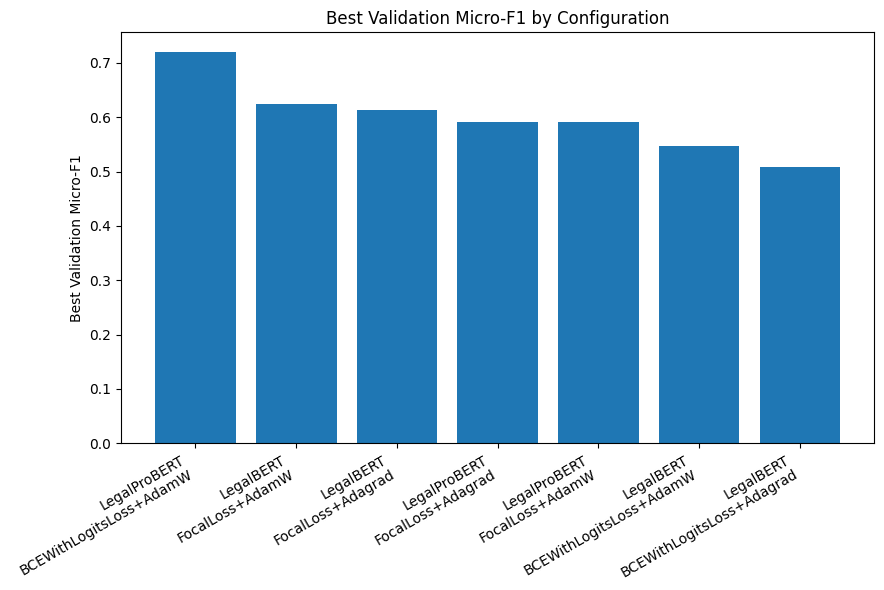

,Model,Loss,Optimizer,Val Micro-F1
0,LegalProBERT,BCEWithLogitsLoss,AdamW,0.7201
1,LegalBERT,FocalLoss,AdamW,0.6251
2,LegalBERT,FocalLoss,Adagrad,0.6133
3,LegalProBERT,FocalLoss,Adagrad,0.5908
4,LegalProBERT,FocalLoss,AdamW,0.5907
5,LegalBERT,BCEWithLogitsLoss,AdamW,0.5474
6,LegalBERT,BCEWithLogitsLoss,Adagrad,0.5075


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Enter your best Validation Micro-F1 for each config
rows = [
    ("LegalProBERT", "BCEWithLogitsLoss", "AdamW", 0.7201),
    ("LegalBERT",    "FocalLoss",         "AdamW", 0.6251),
    ("LegalProBERT", "FocalLoss",         "Adagrad", 0.5908),
    ("LegalProBERT", "FocalLoss",         "AdamW", 0.5907),
    ("LegalBERT",    "BCEWithLogitsLoss", "AdamW", 0.5474),
    ("LegalBERT",    "BCEWithLogitsLoss", "Adagrad", 0.5075),
    ("LegalBERT",    "FocalLoss", "Adagrad", 0.6133),

]

df = pd.DataFrame(rows, columns=["Model","Loss","Optimizer","Val Micro-F1"])
df = df.sort_values("Val Micro-F1", ascending=False).reset_index(drop=True)

# Bar chart (matplotlib; single plot; no custom colors)
plt.figure(figsize=(9,6))
labels = [f"{b}\n{l}+{o}" for b,l,o in df[["Model","Loss","Optimizer"]].values]
plt.bar(range(len(df)), df["Val Micro-F1"])
plt.xticks(range(len(df)), labels, rotation=30, ha="right")
plt.ylabel("Best Validation Micro-F1")
plt.title("Best Validation Micro-F1 by Configuration")
plt.tight_layout()
plt.show()

display(df)

